In [55]:
from util import go_to_project_root
go_to_project_root()

CWD cambiado a la raíz del proyecto: /home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/Homeworks


In [56]:
import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np 

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
results = pd.read_csv('./presentation/backup/bigtable_multiprocess.csv')


In [75]:
matrix = results.iloc[:, 1:]
df_filtrado = matrix.apply(lambda x: np.where(x < 0.05, 1, 0))
vals = df_filtrado.values.sum(0)/df_filtrado.shape[0]

vals = pd.DataFrame(vals, columns=['tasa de rechazo (%)'])
vals['model'] = list(results.columns[1:])
vals

,tasa de rechazo (%),model
0,0.00,DF
1,0.00,ADF
2,0.16,PP
3,0.32,KPSS
4,0.00,Perron
5,0.00,Zivot-Andrews
6,0.02,Bierens
7,0.00,Murray-Nelson
8,0.82,GLS


Gráfico guardado como 'tasa_rechazo_bar_plot.png'


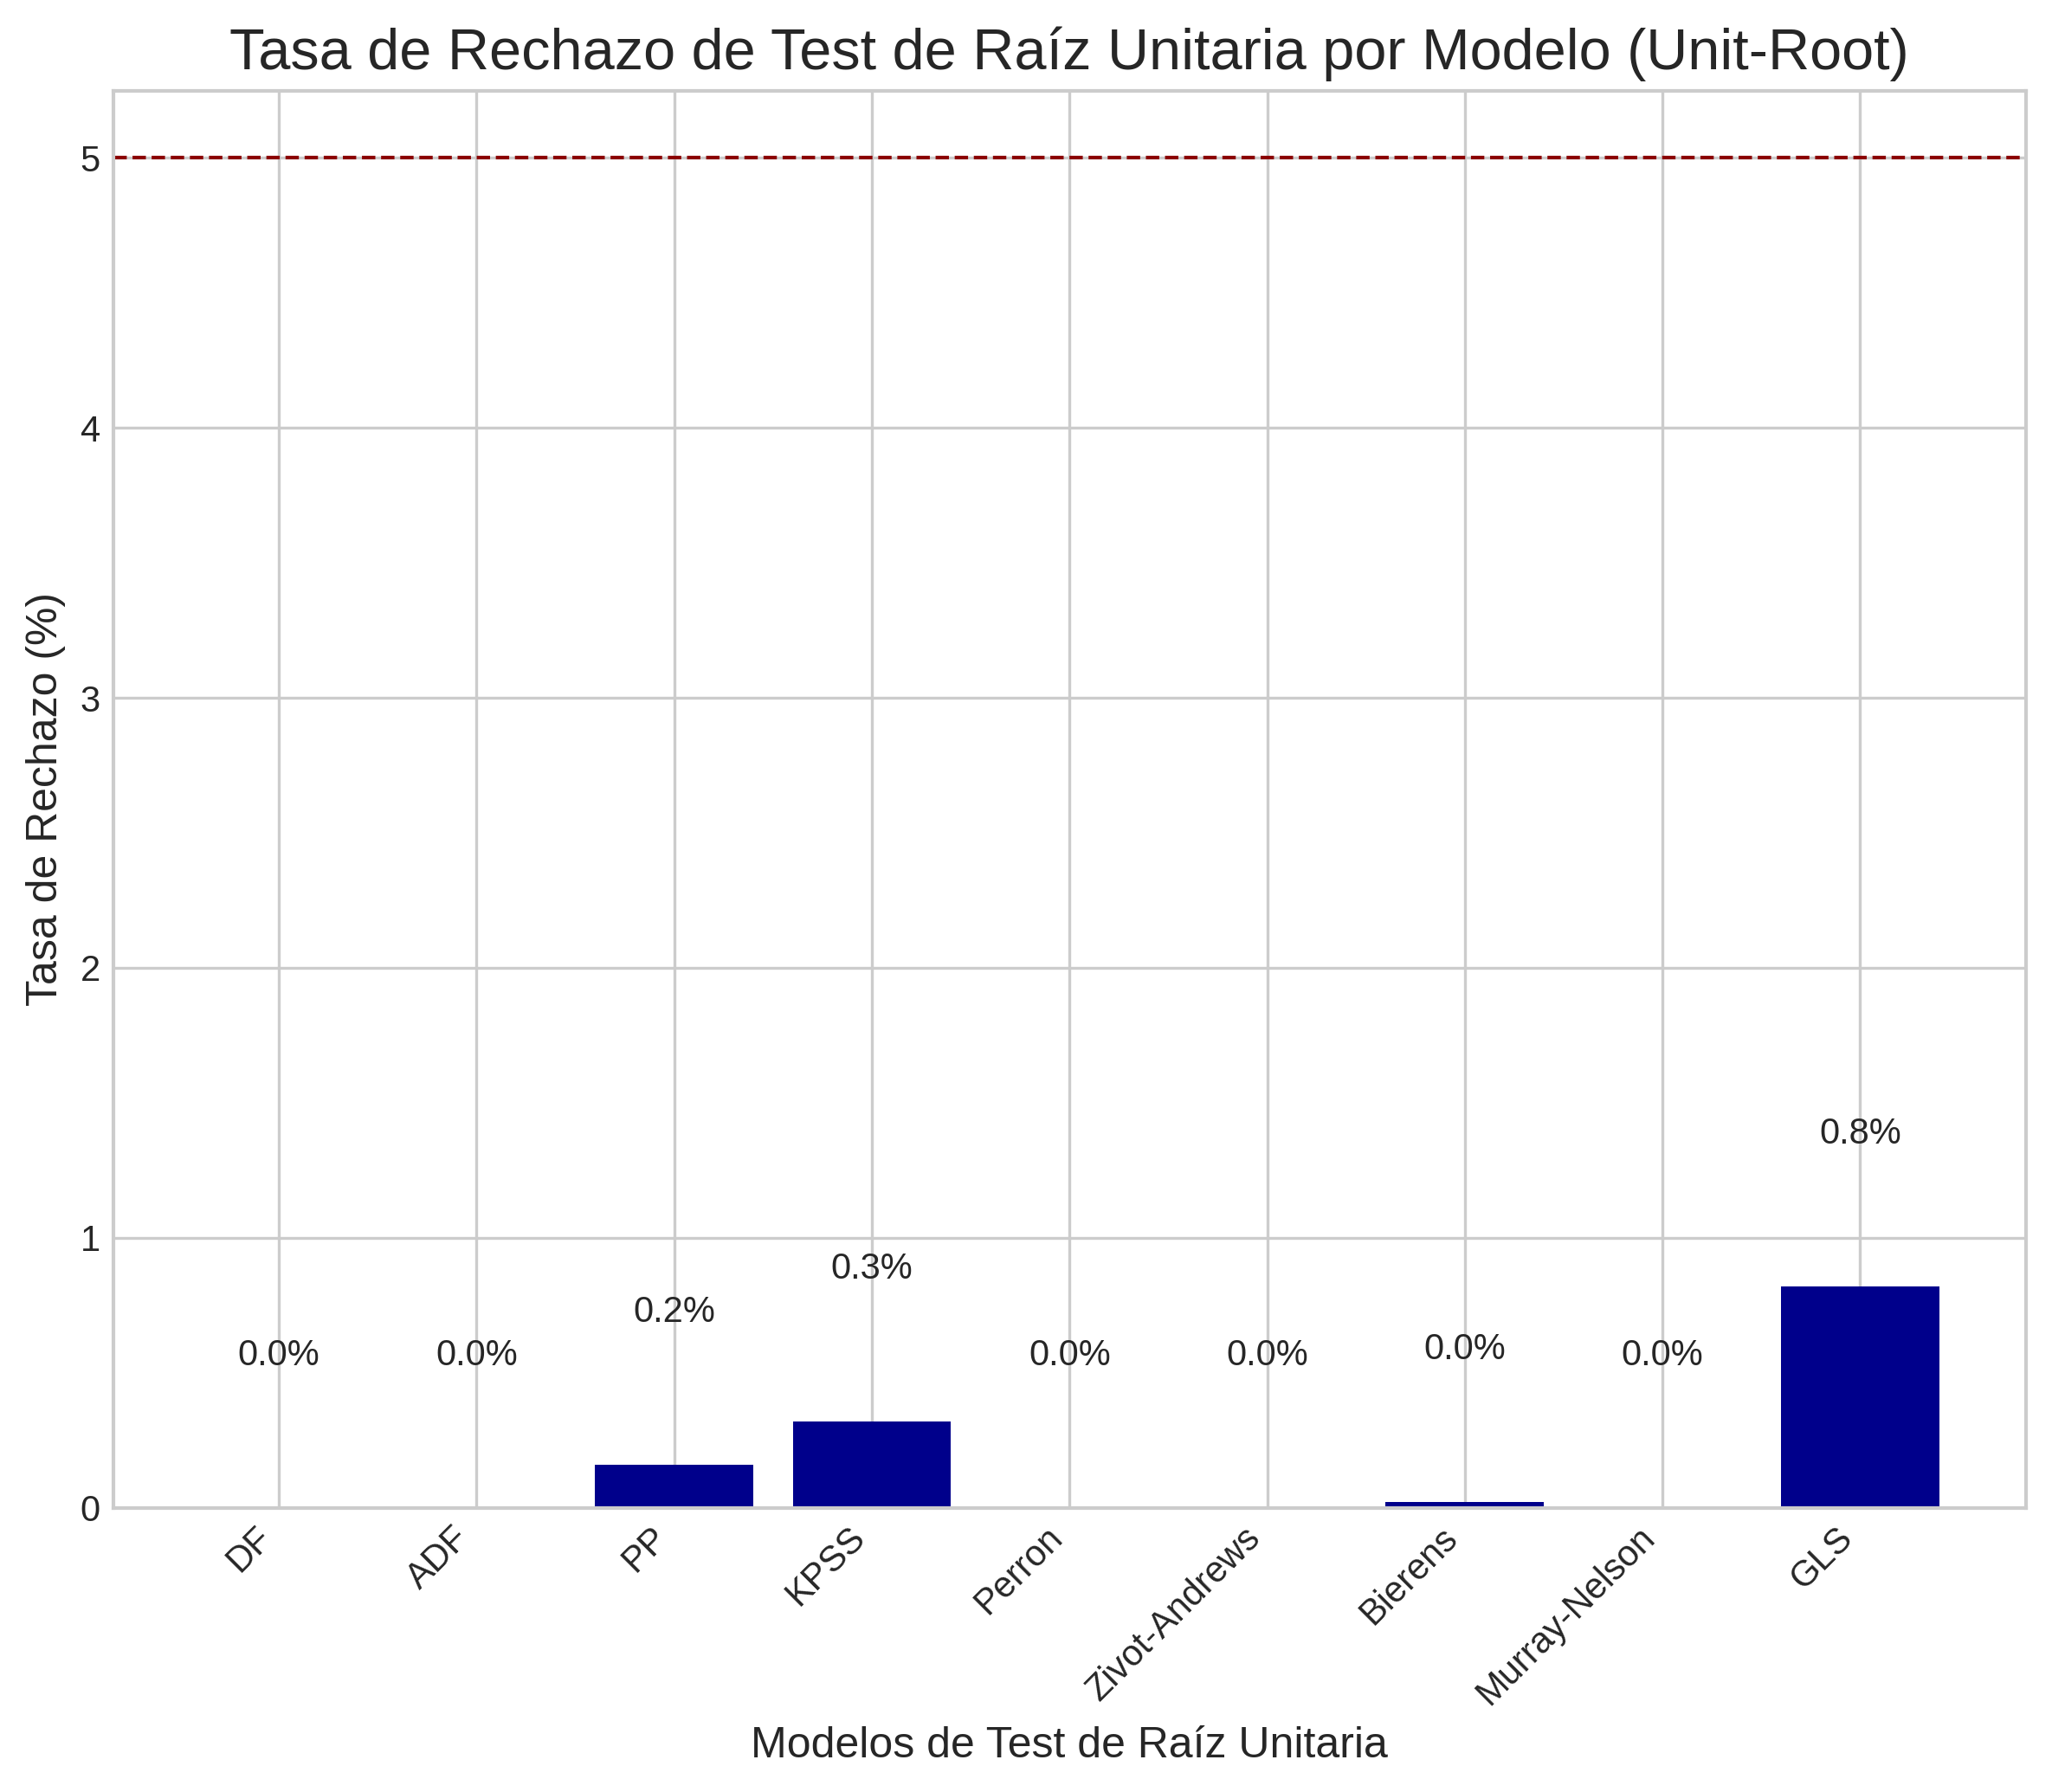

In [76]:
# Eliminar el valor 'Intercepto' para evitar que distorsione el gráfico
results_plot = vals[vals['model'] != 'Intercepto'].copy()

# Diccionario para mapear los nombres cortos a nombres descriptivos
# (he completado la lista con los modelos faltantes)
model_names_map = {
    'df': 'Dickey-Fuller',
    'ADF-c(k=0)': 'Augmented DF',
    'pp - Sin constante ni tendencia': 'Phillip-Perron (sin cte)',
    'pp - Con constante y tendencia': 'Phillip-Perron (con cte)',
    'kpss_c': 'KPSS (con cte)',
    'kpss_ct': 'KPSS (con cte y trend)',
    'model_a': 'Perron Modelo A',
    'model_b': 'Perron Modelo B',
    'model_c': 'Perron Modelo C',
    'za_model_a': 'Zivot-Andrews Modelo A',
    'za_model_b': 'Zivot-Andrews Modelo B',
    'za_model_c': 'Zivot-Andrews Modelo C',
    'Bierens(m=3, k=1)': 'Bierens',
    'murray-nelson': 'Murray-Nelson'
}

# Reemplazar los nombres en el DataFrame
results_plot['model'] = results_plot['model'].replace(model_names_map)

# Configurar el gráfico de barras
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 7),dpi=300)

# Crear el gráfico de barras
ax.bar(
    results_plot['model'],
    results_plot['tasa de rechazo (%)'],
    color='darkblue'
)
ax.axhline(y=5, color='darkred', linestyle='--', label='5% en Eje Y', lw=1)
# Añadir título y etiquetas
ax.set_title(
    'Tasa de Rechazo de Test de Raíz Unitaria por Modelo (Unit-Root)',
    fontsize=16
)
ax.set_xlabel('Modelos de Test de Raíz Unitaria', fontsize=12)
ax.set_ylabel('Tasa de Rechazo (%)', fontsize=12)

# Rotar las etiquetas del eje X para mejor lectura
plt.xticks(rotation=45, ha='right')

# Añadir las etiquetas de valor sobre cada barra
for i, val in enumerate(results_plot['tasa de rechazo (%)']):
    ax.text(
        i, val + 0.5, str(round(val, 1)) + '%',
        ha='center', va='bottom', fontsize=10
    )

# Ajustar los márgenes para que todo sea visible
plt.tight_layout()

# Guardar el gráfico
plt.savefig('tasa_rechazo_bar_plot.png')
print("Gráfico guardado como 'tasa_rechazo_bar_plot.png'")